In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import matplotlib.lines as mlines
import ast
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src"))
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src", "utils"))
import env_loader
env_loader.load_env()
from constants import target_dict_mapping

def target_category(target: str) -> str:
    """
    Categorize target based on naming patterns.
    
    Parameters:
    -----------
    target : str
        Target name
        
    Returns:
    --------
    str
        Target category ('lab', 'symptom', or 'clinic')
    """
    if 'grade2plus' in target:
        return 'lab'
    elif 'change' in target:
        return 'symptom'
    else:
        return 'clinic'
    
def plot_target_specific_auc_bootstrapped(
    df: pd.DataFrame,
    split: str = "test",
    methods_order: List[str] = None,
    target_type_order: List[str] = None,
    figsize: Tuple[int, int] = (10, 6),
    title: str = None,
    ci: float = 0.95
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create target-specific AUC plot with bootstrapped confidence intervals.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: method, split, boot_id, auc, target
    split : str
        Which split to filter on ('test' or 'inference')
    methods_order : list, optional
        Ordered list of methods to include
    target_type_order : list, optional
        Order of target types for grouping
    figsize : tuple, optional
        Figure size (width, height)
    title : str, optional
        Plot title
    ci : float, optional
        Confidence interval width (default 0.95 for 95% CI)

    Returns:
    --------
    Tuple[plt.Figure, plt.Axes]
    """
    alpha = (1 - ci) / 2

    # --- Preprocessing ---
    df = df.copy()

    # Filter to requested split
    df = df[df["split"] == split]

    # Drop nlp-count
    df = df[df["method"] != "nlp-count"]

    # Rename nlp-tfidf -> bag of words
    df["method"] = df["method"].replace("nlp-tfidf", "bag of words")

    # Apply target_category to get target_type
    df["target_type"] = df["target"].apply(target_category)

    # Map target to target name
    df["target_label"] = df["target"].str.replace("_", "-").map(target_dict_mapping)

    # --- Aggregate bootstrap samples ---
    agg = (
        df.groupby(["method", "target", "target_label", "target_type"])["auc"]
        .agg(
            auc_median="median",
            ci_lower=lambda x: x.quantile(alpha),
            ci_upper=lambda x: x.quantile(1 - alpha),
        )
        .reset_index()
    )

    # --- Method ordering ---
    if methods_order is None:
        methods_order = ["tabular", "bag of words", "finetune", "prompting"]
    methods_order = [m for m in methods_order if m in agg["method"].unique()]

    # --- Target type ordering ---
    if target_type_order is None:
        target_type_order = ["symptom", "lab", "clinic"]

    if title is None:
        title = f"Model AUC with {int(ci*100)}% CI by Method and Target — {split.capitalize()}"

    # --- Sort targets by type then name ---
    agg["target_type"] = pd.Categorical(
        agg["target_type"], categories=target_type_order, ordered=True
    )
    agg = agg.sort_values(["target_type", "target", "method"])

    agg = agg.sort_values(["target_type", "target_label", "method"])  # <-- sort by target_label

    unique_targets = agg["target_label"].unique()                      # <-- use target_label
    x_positions = {target: i for i, target in enumerate(unique_targets)}

    # --- Colors & offsets ---
    colors = ['#0072B2', '#009E73', '#CC79A7', '#E69F00']
    if len(methods_order) > len(colors):
        colors = sns.color_palette("Set2", len(methods_order))

    method_offset = np.linspace(-0.2, 0.2, len(methods_order))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    for m_idx, method in enumerate(methods_order):
        subset = agg[agg["method"] == method]
        for _, row in subset.iterrows():
            x = x_positions[row["target_label"]] + method_offset[m_idx]
            ax.vlines(x=x, ymin=row["ci_lower"], ymax=row["ci_upper"],
                      color=colors[m_idx], alpha=0.6)
            ax.scatter(x, row["auc_median"], color=colors[m_idx], s=60)

    # X-axis
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha="right")
    ax.tick_params(axis='x', which='both', length=0)

    # Labels
    ax.set_ylabel("AUC")
    ax.set_title(title, pad=10)

    # Reference line
    ax.axhline(0.5, color="gray", linestyle="--", lw=0.7, alpha=0.6)

    # Group separators
    group_boundaries = (
        agg.groupby("target_type", observed=True)["target_label"]
        .unique()
        .apply(lambda x: x_positions[x[-1]] + 0.5)
    )
    for _, x_sep in group_boundaries[:-1].items():
        ax.axvline(x=x_sep, color="lightgray", linestyle=":", lw=0.8)

    # Legend
    for m_idx, method in enumerate(methods_order):
        ax.scatter([], [], color=colors[m_idx], label=method, s=60)
    ax.legend(title="Method", loc='upper left', framealpha=0.9)

    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(False)
    plt.tight_layout()

    return fig, ax

In [5]:
WORK_DIR = os.environ.get("WORK_DIR_HOME", "")
df_tidy_sensitivity = pd.read_csv(os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/sensitivity_analysis_grade2plus_bootstrap.csv'))

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Model AUC with 95% CI by Method and Target — Test'}, ylabel='AUC'>)

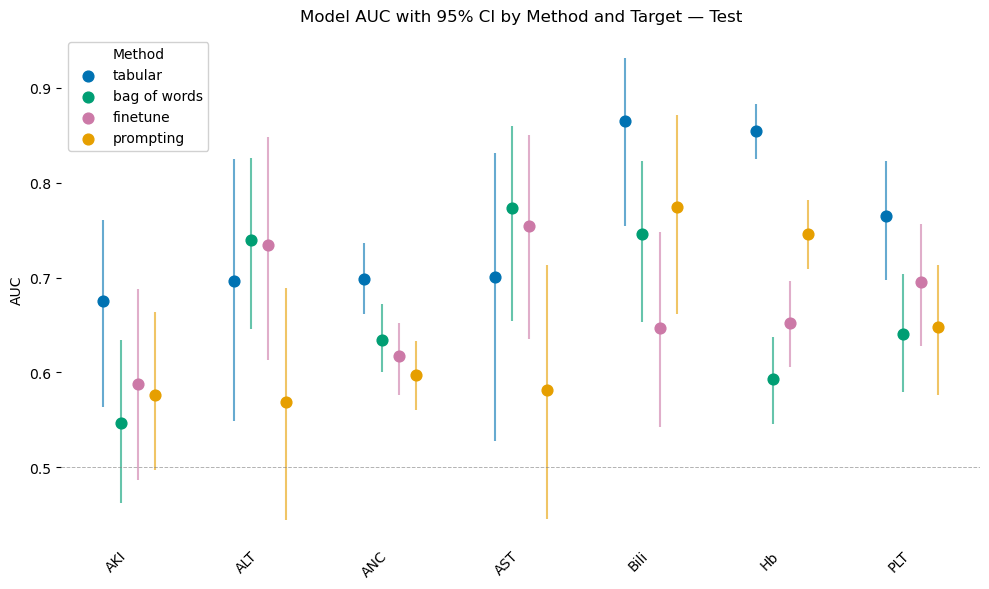

In [6]:
plot_target_specific_auc_bootstrapped(df_tidy_sensitivity, split="test")

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Model AUC with 95% CI by Method and Target — Inference'}, ylabel='AUC'>)

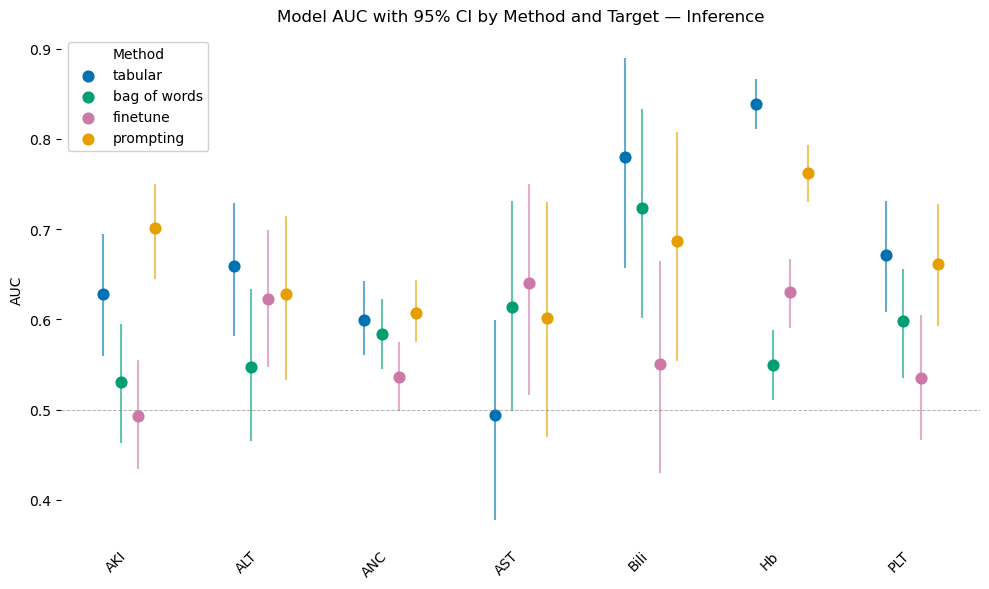

In [7]:
plot_target_specific_auc_bootstrapped(df_tidy_sensitivity, split="inference")

In [8]:
def plot_target_specific_auc_comparison(
    df_v1: pd.DataFrame,
    df_v2: pd.DataFrame,
    split: str = "test",
    methods_order: List[str] = None,
    target_type_order: List[str] = None,
    figsize: Tuple[int, int] = (14, 10),
    title: str = None,
    ci: float = 0.95,
    fig_size_mm: Tuple[float, float] = None,
) -> Tuple[plt.Figure, np.ndarray]:
    """
    Create a 2x2 subplot comparing AUC with bootstrapped CIs across two patient
    populations (v1 = all patients, v2 = normal patients), one subplot per method.

    Parameters:
    -----------
    df_v1 : pd.DataFrame
        DataFrame for version 1 (all patients). Columns: method, split, boot_id, auc, target
    df_v2 : pd.DataFrame
        DataFrame for version 2 (normal patients). Same structure as df_v1.
    split : str
        Which split to filter on ('test' or 'inference')
    methods_order : list, optional
        Ordered list of methods to include (max 4 for 2x2 grid)
    target_type_order : list, optional
        Order of target types for grouping
    figsize : tuple, optional
        Figure size in inches (width, height) — used only if fig_size_mm is None
    title : str, optional
        Overall figure title (unused, kept for API compatibility)
    ci : float, optional
        Confidence interval width (default 0.95 for 95% CI)
    fig_size_mm : tuple, optional
        Figure size as (width_mm, height_mm). Overrides figsize if provided.

    Returns:
    --------
    Tuple[plt.Figure, np.ndarray]
        Figure and 2x2 array of axes
    """

    fontsize_axes = 4
    fontsize_legend = 4

    if fig_size_mm is not None:
        figsize = (fig_size_mm[0] / 25.4, fig_size_mm[1] / 25.4)

    alpha = (1 - ci) / 2

    METHOD_COLORS = {
        "tabular":      '#a1d4cc',
        "bag of words": '#eee5bb',
        "finetune":     '#d4a1cc',
        "prompting":    '#c4e5f6',
    }

    # Visual encoding for the two populations
    POP_STYLES = {
        "all patients":    dict(linestyle="-",  marker="o", label="All patients"),
        "normal patients": dict(linestyle="--", marker="s", label="Normal patients"),
    }

    def preprocess(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = df[df["split"] == split]
        df = df[df["method"] != "nlp-count"]
        df["method"] = df["method"].replace("nlp-tfidf", "bag of words")
        df["target_type"] = df["target"].apply(target_category)
        df["target_label"] = df["target"].str.replace("_", "-").map(target_dict_mapping)
        return df

    def aggregate(df: pd.DataFrame) -> pd.DataFrame:
        return (
            df.groupby(["method", "target", "target_label", "target_type"])["auc"]
            .agg(
                auc_median="median",
                ci_lower=lambda x: x.quantile(alpha),
                ci_upper=lambda x: x.quantile(1 - alpha),
            )
            .reset_index()
        )

    agg_v1 = aggregate(preprocess(df_v1))
    agg_v2 = aggregate(preprocess(df_v2))

    # --- Ordering ---
    if methods_order is None:
        methods_order = ["tabular", "bag of words", "finetune", "prompting"]
    # Only keep methods present in both datasets
    available = set(agg_v1["method"].unique()) | set(agg_v2["method"].unique())
    methods_order = [m for m in methods_order if m in available][:4]  # cap at 4 for 2x2

    if target_type_order is None:
        target_type_order = ["symptom", "lab", "clinic"]

    def prepare_agg(agg: pd.DataFrame) -> pd.DataFrame:
        agg["target_type"] = pd.Categorical(
            agg["target_type"], categories=target_type_order, ordered=True
        )
        return agg.sort_values(["target_type", "target_label", "method"])

    agg_v1 = prepare_agg(agg_v1)
    agg_v2 = prepare_agg(agg_v2)

    # Build x_positions from the union of both datasets' target_labels, in sorted order
    all_targets_ordered = (
        pd.concat([agg_v1[["target", "target_label", "target_type"]],
                   agg_v2[["target", "target_label", "target_type"]]])
        .drop_duplicates()
        .assign(target_type=lambda d: pd.Categorical(
            d["target_type"], categories=target_type_order, ordered=True))
        .sort_values(["target_type", "target_label"])
    )
    common_targets = set(agg_v1["target_label"].unique()) & set(agg_v2["target_label"].unique())
    all_targets_ordered = all_targets_ordered[all_targets_ordered["target_label"].isin(common_targets)]
    # Also filter the aggregated dataframes to common targets only
    agg_v1 = agg_v1[agg_v1["target_label"].isin(common_targets)]
    agg_v2 = agg_v2[agg_v2["target_label"].isin(common_targets)]
    unique_target_labels = all_targets_ordered["target_label"].unique()
    x_positions = {t: i for i, t in enumerate(unique_target_labels)}

    # Group separators derived from the union ordering
    group_boundaries = (
        all_targets_ordered.groupby("target_type", observed=True)["target_label"]
        .unique()
        .apply(lambda x: x_positions[x[-1]] + 0.5)
    )

    # --- 2x2 subplot grid ---
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=False)
    axes_flat = axes.flatten()

    # Hide unused subplots if fewer than 4 methods
    for i in range(len(methods_order), 4):
        axes_flat[i].set_visible(False)

    pop_offset = [-0.15, 0.15]   # v1 left, v2 right of each x position

    for ax_idx, method in enumerate(methods_order):
        ax = axes_flat[ax_idx]
        color = METHOD_COLORS.get(method, "#333333")

        for v_idx, (agg, pop_name) in enumerate(
            [(agg_v1, "all patients"), (agg_v2, "normal patients")]
        ):
            style = POP_STYLES[pop_name]
            subset = agg[agg["method"] == method]

            for _, row in subset.iterrows():
                x = x_positions[row["target_label"]] + pop_offset[v_idx]
                ax.vlines(
                    x=x,
                    ymin=row["ci_lower"],
                    ymax=row["ci_upper"],
                    color=color,
                    linestyle=style["linestyle"],
                    linewidth=0.8,
                )
                ax.scatter(
                    x, row["auc_median"],
                    color=color,
                    marker=style["marker"],
                    s=15,
                    zorder=3,
                )

        # Reference line
        ax.axhline(0.5, color="gray", linestyle="--", lw=0.8)

        # Group separators
        for _, x_sep in group_boundaries[:-1].items():
            ax.axvline(x=x_sep, color="gray", linestyle="--", lw=0.8)

        # Subplot title (no bold)
        ax.set_title(method, fontsize=fontsize_axes, fontweight="normal")

        # Y-axis label on all subplots
        ax.set_ylabel("AUC", fontsize=fontsize_axes)

        # Remove all spines except left (y-axis) and bottom (x-axis)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.0)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_linewidth(1.0)
        ax.spines['bottom'].set_color('black')
        ax.grid(False)

        ax.tick_params(axis='both', labelsize=fontsize_axes, pad=1)

    for ax in axes_flat[:len(methods_order)]:
        ax.set_xticks(list(x_positions.values()))
        ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha="right",
                           fontsize=fontsize_axes)
        ax.tick_params(axis='x', which='both', length=0, labelbottom=True)  # <-- labelbottom=True

    # Single shared legend for population styles (top of figure)
    legend_handles = [
        mlines.Line2D([], [], color="gray", linestyle=style["linestyle"],
                      marker=style["marker"], markersize=4, label=pop_name.capitalize())
        for pop_name, style in POP_STYLES.items()
    ]
    fig.legend(
        handles=legend_handles,
        title="Population",
        title_fontsize=fontsize_legend,
        fontsize=fontsize_legend,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 1.02),
        framealpha=0.9,
    )

    plt.tight_layout(pad=0.5)
    fig.set_size_inches(figsize[0], figsize[1])

    return fig, axes

In [3]:
df_tidy_aggregate = pd.read_csv(os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/aggregate_bootstrap_results.csv'))

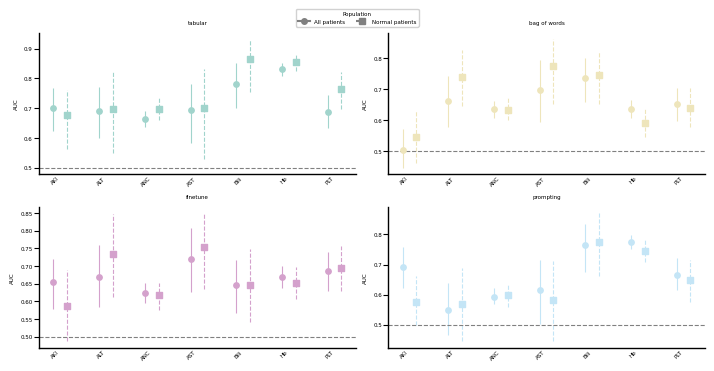

In [ ]:
fig, _ = plot_target_specific_auc_comparison(df_tidy_aggregate, df_tidy_sensitivity, "test", fig_size_mm=(180,90))
fig.savefig("sensitivity_analysis_EPR.svg")

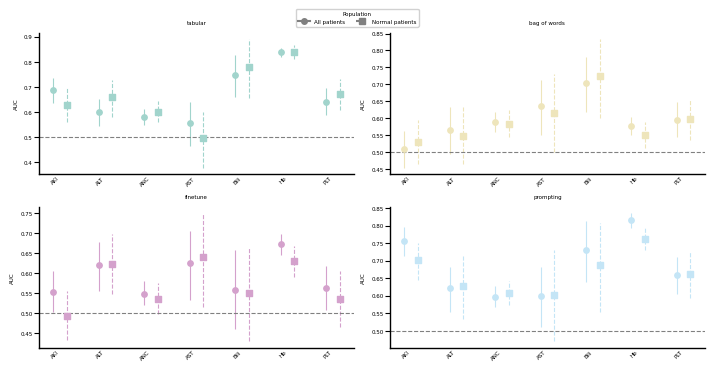

In [ ]:
fig, _ = plot_target_specific_auc_comparison(df_tidy_aggregate, df_tidy_sensitivity, "inference", fig_size_mm=(180,90))
fig.savefig("sensitivity_analysis_EPIC.svg")